# Signal Analysis

Signal analysis focuses on extracting information from a signal, particularly its frequency content and how that content changes with time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy import fft

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

In [3]:
def plot(f, x, label):
    plt.figure(figsize=(5, 5))
    plt.plot(f, x, "r")
    plt.xlim(0, 20)
    plt.xlabel(r"$f$")
    plt.ylabel(label)
    plt.tight_layout()
    plt.show()

The signal used in this notebook is the same type of composite signal introduced in the generation and processing notebooks. It contains several oscillatory components, modulation, a decaying oscillation, and Gaussian noise. The signal is sampled at

$$
f_s = 1000\ \text{Hz}
$$

over a duration of

$$
T=10\ \text{s}.
$$

In [4]:
fs, T = 1000, 10
t = np.linspace(0, T, int(fs * T), endpoint=False)
x_clean = (np.sin(8 * np.pi * t)
    + 0.2 * (1 + np.sin(10 * np.pi * t)) * np.sin(12 * np.pi * t)
    + 0.2 * np.sin(4 * np.pi * t + np.sin(6 * np.pi * t))
    + 0.5 * np.exp(-t) * np.cos(2 * np.pi * t))
x_noisy = x_clean + np.random.normal(0, 0.1, len(t))

## Fourier Transform

The Fourier transform represents a time-domain signal in terms of its frequency components. For a continuous signal $x(t)$, the Fourier transform is

$$
X(f) = \int_{-\infty}^{\infty} x(t)e^{-2\pi i f t}\,dt.
$$

For a discrete signal, the Fast Fourier Transform (FFT) provides an efficient numerical implementation of the discrete Fourier transform. For the real-valued signal used here, only the non-negative frequencies are required:

In [5]:
freq = fft.rfftfreq(len(x_noisy), d=1/fs)
X = fft.rfft(x_noisy)
power = 2 * np.abs(X)**2 / len(x_noisy)**2
magnitude = 2 * np.abs(X) / len(x_noisy)

The frequency array is determined by the sampling frequency and the number of samples.

## Amplitude Spectrum

The magnitude of the Fourier transform describes the strength of each frequency component. For the normalization used here, the single-sided amplitude spectrum is

$$
A(f)= \frac{2|X(f)|}{N},
$$

where $N$ is the number of samples. The amplitude spectrum can be plotted as

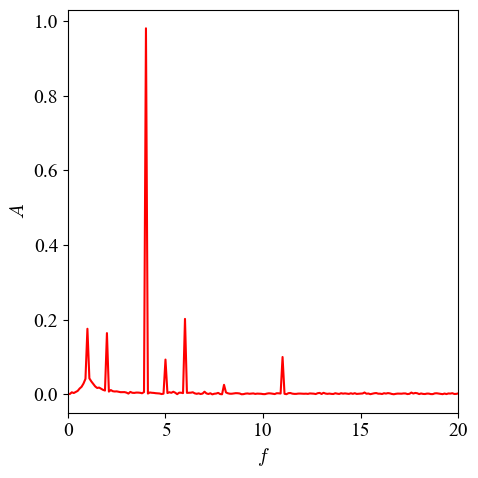

In [6]:
plot(freq, magnitude, r"$A$")

Peaks in the amplitude spectrum indicate frequencies that contribute strongly to the signal.

The dominant frequencies can be identified computationally using `find_peaks`:

In [7]:
peaks, _ = signal.find_peaks(magnitude, height=0.05)
for f in freq[peaks]:
    print(f"{f:.2f} Hz")

1.00 Hz
2.00 Hz
4.00 Hz
5.00 Hz
6.00 Hz
11.00 Hz


This provides a numerical way to identify the main frequency components rather than estimating them directly from the plot.

## Power Spectrum

The power spectrum describes how the signal power is distributed across frequency. With the normalization used here,

$$
P(f) = \frac{2|X(f)|^2}{N^2}.
$$

The resulting spectrum can be plotted directly:

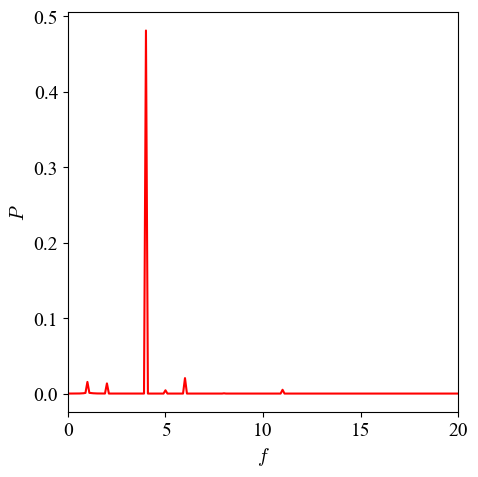

In [8]:
plot(freq, power, r"$P$")

A logarithmic vertical scale can also be useful when the spectrum contains components with significantly different power:

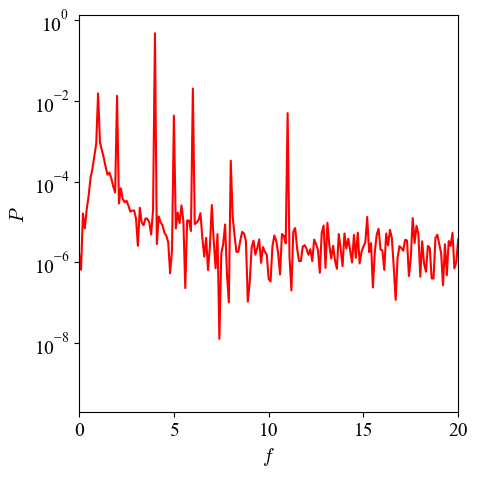

In [9]:
plt.figure(figsize=(5, 5))
plt.semilogy(freq, power, "r")
plt.xlim(0, 20)
plt.xlabel(r"$f$")
plt.ylabel(r"$P$")
plt.tight_layout()
plt.show()

The logarithmic scale makes weaker frequency components easier to distinguish from dominant ones.

## Power Spectral Density

The power spectrum depends on the particular normalization used for the finite signal. Power spectral density (PSD) instead describes how signal power is distributed per unit frequency. SciPy provides the periodogram through

In [10]:
f, Pxx = signal.periodogram(x_noisy, fs)

where $P_{xx}(f)$ represents the estimated power spectral density. The PSD can be visualized on both linear and logarithmic scales:

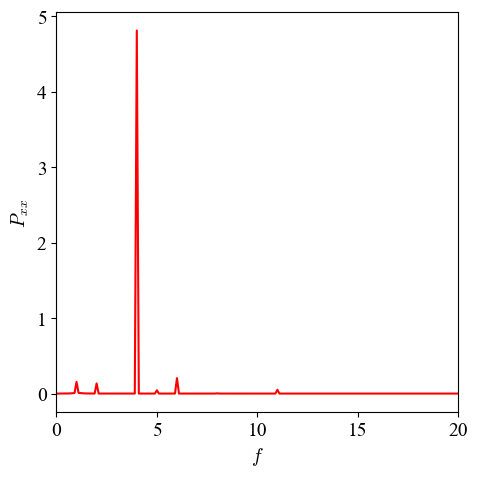

In [11]:
plot(f, Pxx, r"$P_{xx}$")

and

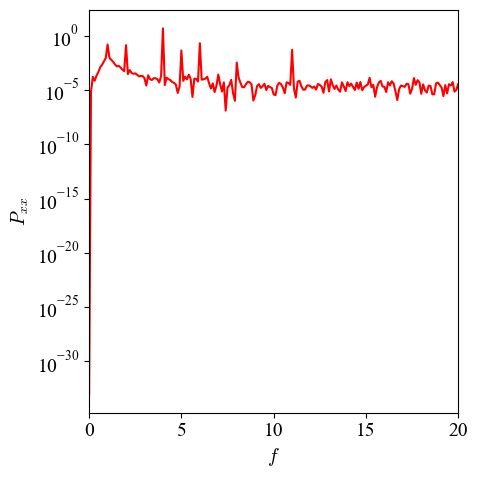

In [12]:
plt.figure(figsize=(5, 5))
plt.semilogy(f, Pxx, "r")
plt.xlim(0, 20)
plt.xlabel(r"$f$")
plt.ylabel(r"$P_{xx}$")
plt.tight_layout()
plt.show()

The peaks of the PSD correspond to frequencies containing a large fraction of the signal's power.

## Spectrogram

A Fourier transform describes the frequency content of the entire signal, but it does not directly show when a particular frequency occurs. For signals whose frequency content changes with time, the signal can instead be divided into shorter segments and analyzed separately. This produces a spectrogram. The spectrogram represents the power spectral density as a function of both time and frequency:

$$
S_{xx}(f,t).
$$

It can be visualized as

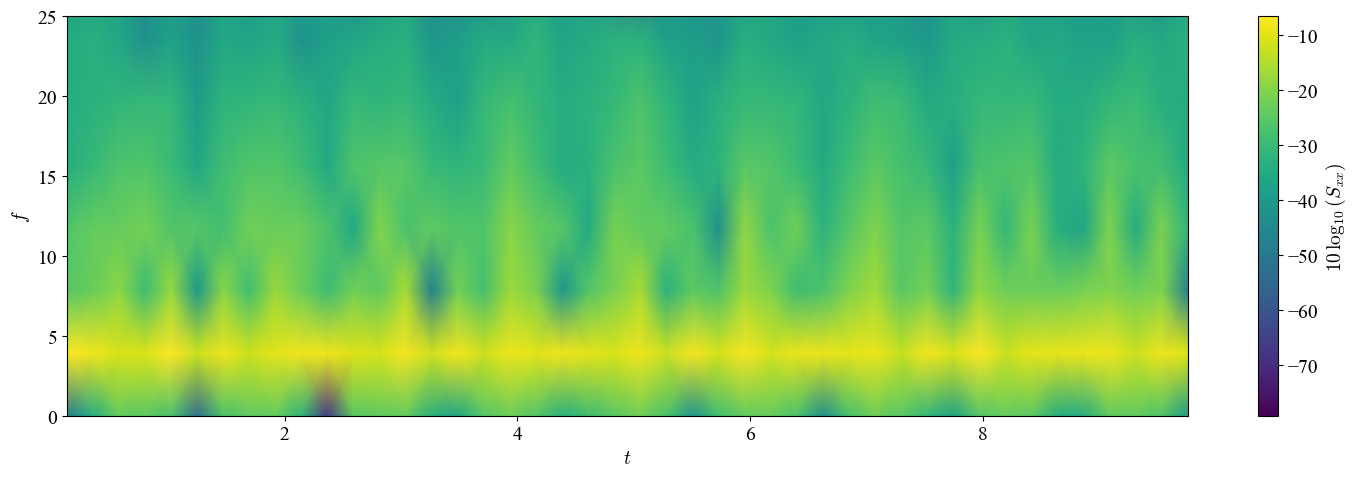

In [13]:
f, tt, Sxx = signal.spectrogram(x_noisy, fs)
plt.figure(figsize=(15, 5))
plt.pcolormesh(tt, f, 10*np.log10(Sxx), shading="gouraud")
plt.colorbar(label=r"$10\,\log_{10}(S_{xx})$")
plt.xlabel(r"$t$")
plt.ylabel(r"$f$")
plt.ylim(0, 25)
plt.tight_layout()
plt.show()

The quantity

$$
10\log_{10}S_{xx}
$$

expresses the power spectral density on a logarithmic decibel scale. The resulting two-dimensional representation shows how the frequency content evolves over time. This is particularly useful for signals containing transient or time-dependent behavior, such as the decaying oscillation and modulation present in the signal used here.

## Short-Time Fourier Transform

The Short-Time Fourier Transform (STFT) provides another time-frequency representation. The STFT can be written conceptually as

$$
Z_{xx}(t,f) = \int x(\tau)w(\tau-t)e^{-2\pi i f\tau}\,d\tau,
$$

where $w(\tau-t)$ is a window function centered around time $t$. Unlike the ordinary Fourier transform, the STFT analyzes the signal locally in time. The magnitude of the STFT is visualized using

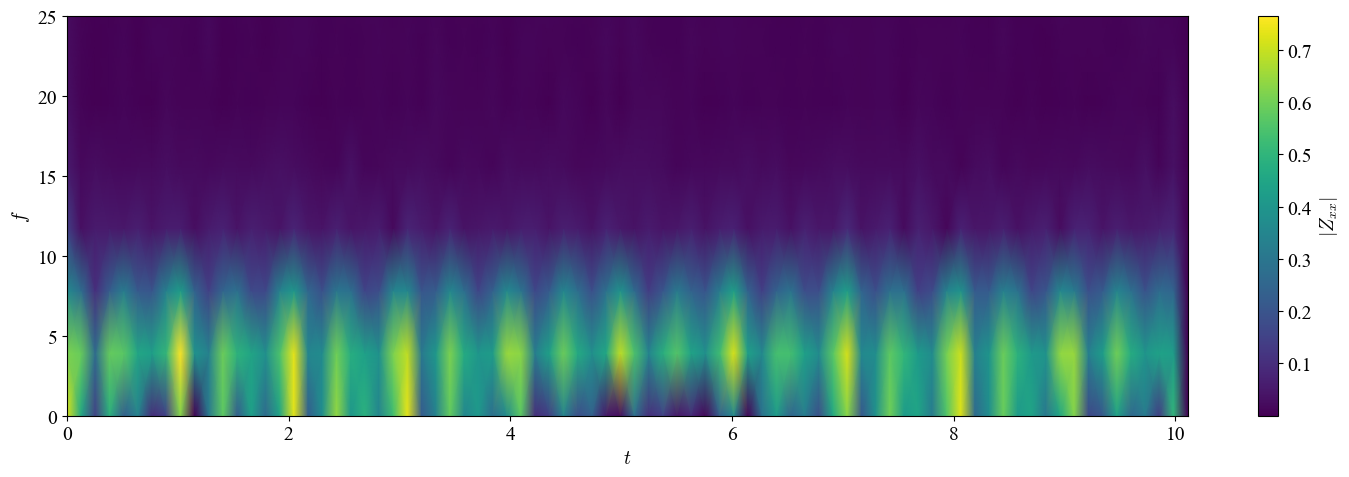

In [14]:
f, tt, Zxx = signal.stft(x_noisy, fs)
plt.figure(figsize=(15, 5))
plt.pcolormesh(tt, f, np.abs(Zxx), shading="gouraud")
plt.colorbar(label=r"$|Z_{xx}|$")
plt.xlabel(r"$t$")
plt.ylabel(r"$f$")
plt.ylim(0, 25)
plt.tight_layout()
plt.show()

The magnitude

$$
|Z_{xx}(t,f)|
$$

indicates the strength of each frequency component at a particular time.